In [1]:
from google.colab import files

# Upload file from your local system
uploaded = files.upload()


Saving loan.csv to loan.csv


In [9]:
import os

# Create the folder structure if it doesn't exist
os.makedirs("data/clean", exist_ok=True)


In [10]:
import pandas as pd

# Load the uploaded dataset
df = pd.read_csv("loan.csv")

#data inspection
print(df.shape)       # rows, columns
df.head()             # first 5 rows
df.info()             # column types
df.describe()         # summary statistics


(614, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [11]:
# Handle missing values
df.fillna({
    'Gender': df['Gender'].mode()[0],
    'Married': df['Married'].mode()[0],
    'Dependents': df['Dependents'].mode()[0],
    'Self_Employed': df['Self_Employed'].mode()[0],
    'LoanAmount': df['LoanAmount'].median(),
    'Loan_Amount_Term': df['Loan_Amount_Term'].mode()[0],
    'Credit_History': df['Credit_History'].mode()[0]
}, inplace=True)

# Encode categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

# Normalize numeric features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols = ['ApplicantIncome','CoapplicantIncome','LoanAmount']
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

# Save cleaned dataset
df_encoded.to_csv("data/clean/loan_clean.csv", index=False)

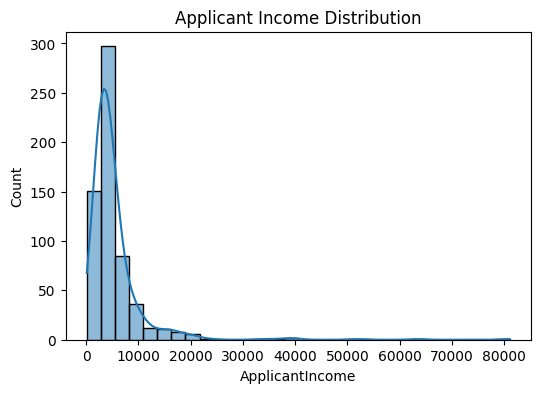

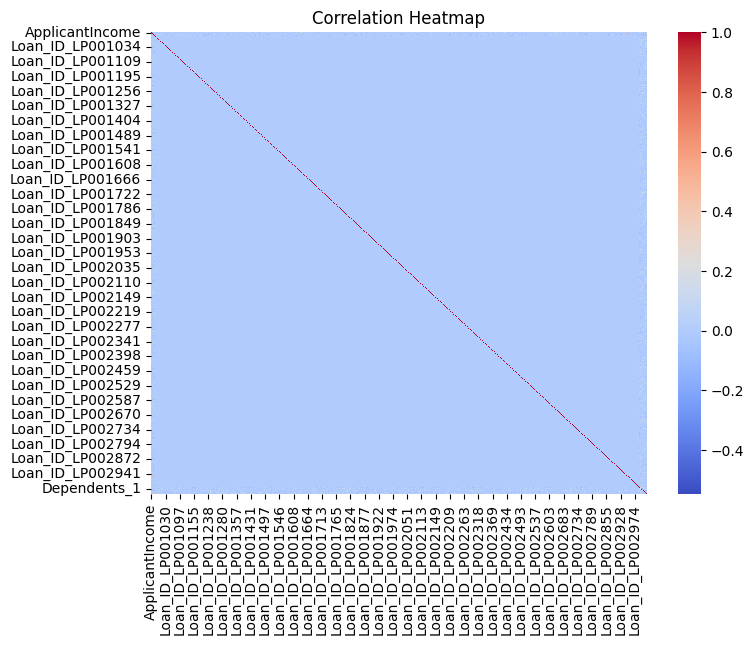

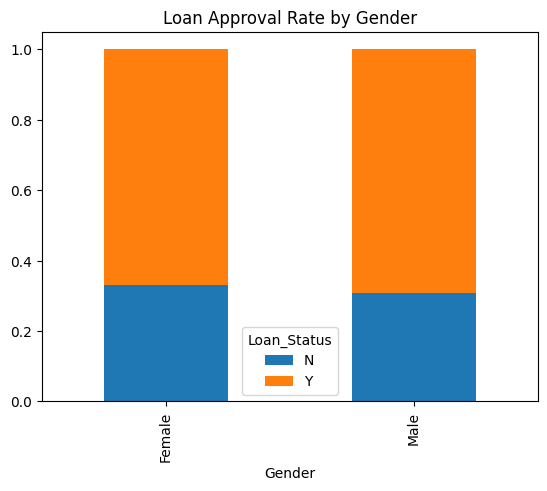

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

import os

# Create the folder structure for plots
os.makedirs("eda/plots", exist_ok=True)

# Distribution plot
plt.figure(figsize=(6,4))
sns.histplot(df['ApplicantIncome'], bins=30, kde=True)
plt.title("Applicant Income Distribution")
plt.savefig("eda/plots/income_distribution.png")

# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df_encoded.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.savefig("eda/plots/correlation_heatmap.png")

# Bias check by gender
bias = df.groupby('Gender')['Loan_Status'].value_counts(normalize=True).unstack()
bias.plot(kind='bar', stacked=True)
plt.title("Loan Approval Rate by Gender")
plt.savefig("eda/plots/bias_check_gender.png")
